In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("netflix_movies_and_tv_merged.csv")

# Check dataset
print(df.shape)
print(df.info())

# Missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill numerical missing values
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("Data Cleaning Completed")

(32000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       32000 non-null  int64  
 1   type          32000 non-null  object 
 2   title         32000 non-null  object 
 3   director      20903 non-null  object 
 4   cast          30639 non-null  object 
 5   country       29737 non-null  object 
 6   date_added    32000 non-null  object 
 7   release_year  32000 non-null  int64  
 8   rating        32000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        30919 non-null  object 
 11  language      32000 non-null  object 
 12  description   28662 non-null  object 
 13  popularity    32000 non-null  float64
 14  vote_count    32000 non-null  int64  
 15  vote_average  32000 non-null  float64
 16  budget        16000 non-null  float64
 17  revenue       16000 non-null  float64
 18  content_type  

In [2]:
print(df.describe())

            show_id  release_year        rating    popularity    vote_count  \
count  3.200000e+04  32000.000000  32000.000000  32000.000000  32000.000000   
mean   3.266129e+05   2017.500000      5.686738     42.617856    412.835219   
std    3.389191e+05      4.609844      2.635722    112.080448   1562.553446   
min    1.890000e+02   2010.000000      0.000000      2.323000      0.000000   
25%    8.212950e+04   2013.750000      5.300000     10.475000      2.000000   
50%    2.096335e+05   2017.500000      6.497000     22.063500     43.000000   
75%    4.468120e+05   2021.250000      7.300000     41.532000    192.000000   
max    1.440471e+06   2025.000000     10.000000   6421.923000  37119.000000   

       vote_average        budget       revenue  
count  32000.000000  3.200000e+04  3.200000e+04  
mean       5.686738  4.383396e+06  1.223154e+07  
std        2.635722  2.105516e+07  7.992251e+07  
min        0.000000  0.000000e+00  0.000000e+00  
25%        5.300000  0.000000e+00  0.0

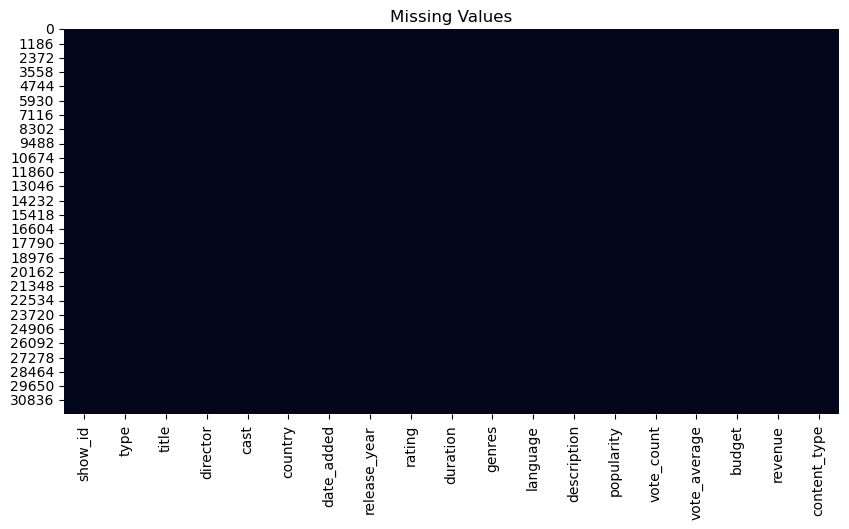

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

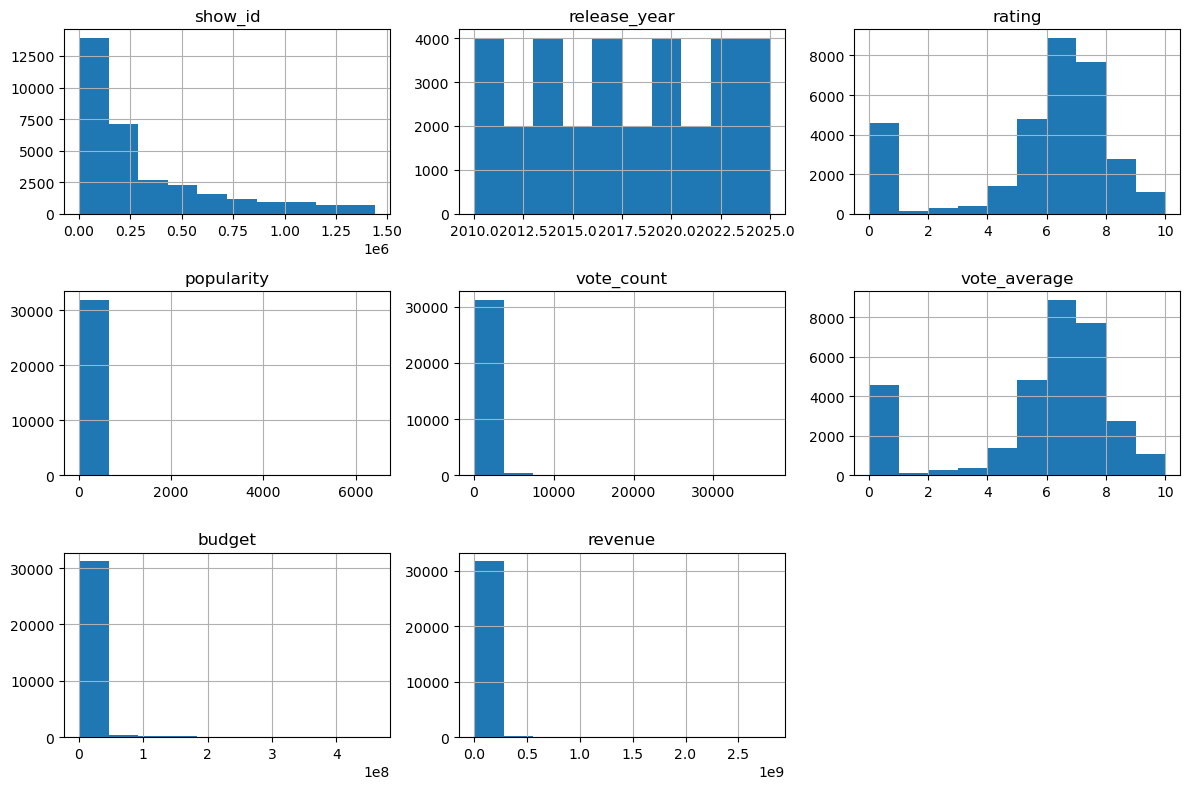

In [4]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

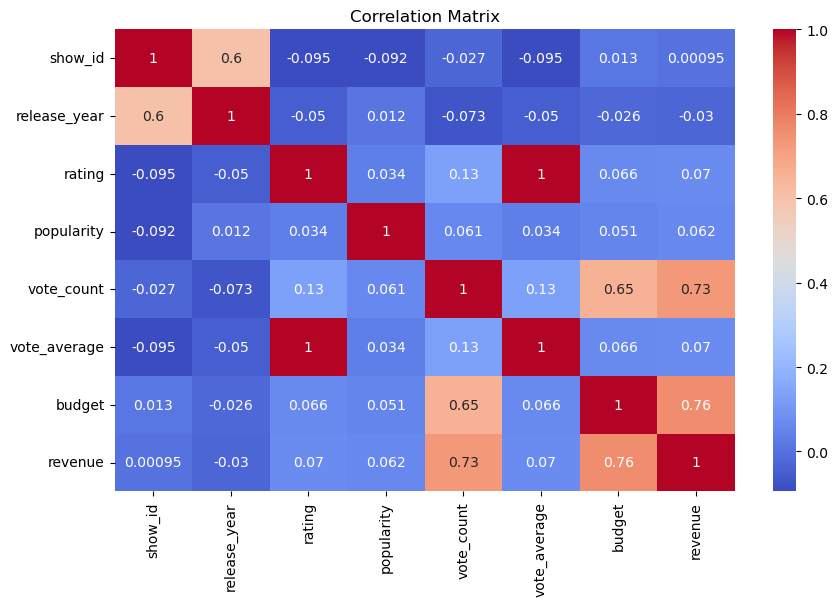

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

X = df[num_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

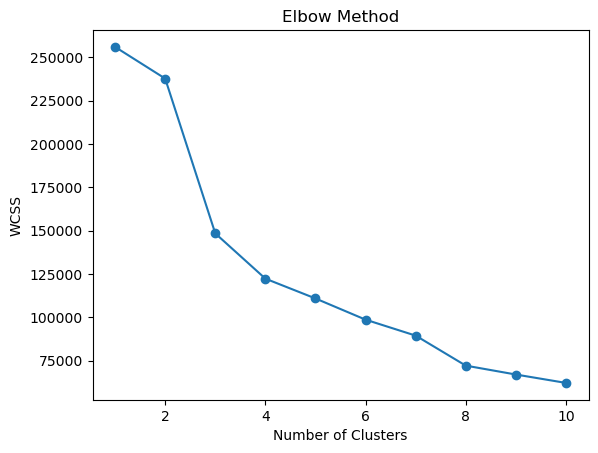

In [7]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df[['Cluster']].head()

,Cluster
0,2
1,2
2,2
3,2
4,2


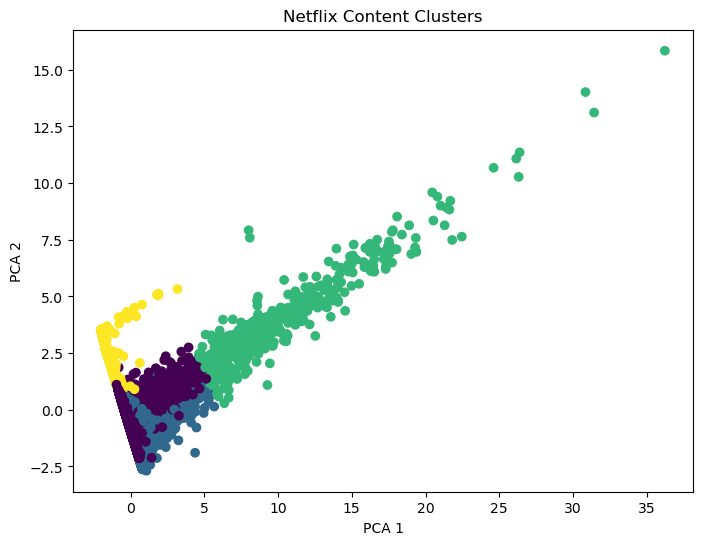

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title("Netflix Content Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [10]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.331


In [11]:
cluster_summary = df.groupby("Cluster")[num_cols].mean()

print(cluster_summary)

               show_id  release_year    rating  popularity   vote_count  \
Cluster                                                                   
0        571807.822332   2021.457722  6.750510   31.849492   287.966141   
1        138459.659113   2014.298113  6.696735   48.534262   351.058251   
2        289575.087045   2016.404858  6.896759  101.120265  9379.993927   
3        361321.708137   2018.604756  0.207760   42.634477     0.666470   

         vote_average        budget       revenue  
Cluster                                            
0            6.750510  2.857108e+06  5.413056e+06  
1            6.696735  2.626075e+06  5.590455e+06  
2            6.896759  1.349835e+08  4.972103e+08  
3            0.207760  3.234158e+05  1.350441e+04  


In [2]:
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv("netflix_movies_and_tv_merged.csv")

# Remove duplicates
df = df.drop_duplicates()

# Select numerical columns only
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

X = df[num_cols]

# Create clustering pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=42, n_init=10))
])

# Train pipeline
pipeline.fit(X)

# Add cluster labels
df["Cluster"] = pipeline.predict(X)

# Save pipeline and column names
joblib.dump(pipeline, "netflix_cluster_pipeline.pkl")
joblib.dump(list(num_cols), "netflix_features.pkl")

# Save clustered dataset
df.to_csv("netflix_movies_and_tv_merged.csv", index=False)

print("Pipeline saved successfully")
print(df["Cluster"].value_counts())

Pipeline saved successfully
Cluster
3    15306
1    11107
2     5088
0      499
Name: count, dtype: int64
